**Google** **Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


***Data*** **Preprocessing**

In [2]:
#Imports used
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import wave
import pylab
from pathlib import Path
from scipy import signal
from scipy.io import wavfile
from sklearn.metrics import confusion_matrix
import itertools
import gc




In [ ]:
import os
import shutil

source_folders = ['/content/drive/MyDrive/training/training-a', '/content/drive/MyDrive/training/training-b', '/content/drive/MyDrive/training/training-c', '/content/drive/MyDrive/training/training-d', '/content/drive/MyDrive/training/training-e', '/content/drive/MyDrive/training/training-f']
destination_folder = '/content/drive/MyDrive/training/all_files'

for source_folder in source_folders:
    for root, dirs, files in os.walk(source_folder):
        for file in files:
            source_file = os.path.join(root, file)
            destination_file = os.path.join(destination_folder, file)
            shutil.copy(source_file, destination_file)


In [3]:
#Input directory where the wav files are stored
input_directory = '/content/drive/MyDrive/training/all_files'

wav_temp = os.listdir(input_directory)
wav = []

for i in range(len(wav_temp)) :
    if(wav_temp[i].endswith(".wav")):
        wav.append(wav_temp[i])

wav.sort()
for i in range(10):

    if(wav[i].endswith(".wav")):
        file_name = wav[i][0:5]

        if(file_name[0] == 'e'):
              file_name = wav[i][0:6]

        with open(input_directory+'/'+file_name+'.hea') as f:
            lines = f.read().splitlines()
            last_line = lines[-1].split()[1]
            print(file_name + " " + last_line)

gc.collect()
# del wav_temp

a0001 Abnormal
a0002 Abnormal
a0003 Abnormal
a0004 Abnormal
a0005 Abnormal
a0006 Abnormal
a0007 Normal
a0008 Abnormal
a0009 Normal
a0010 Abnormal


0

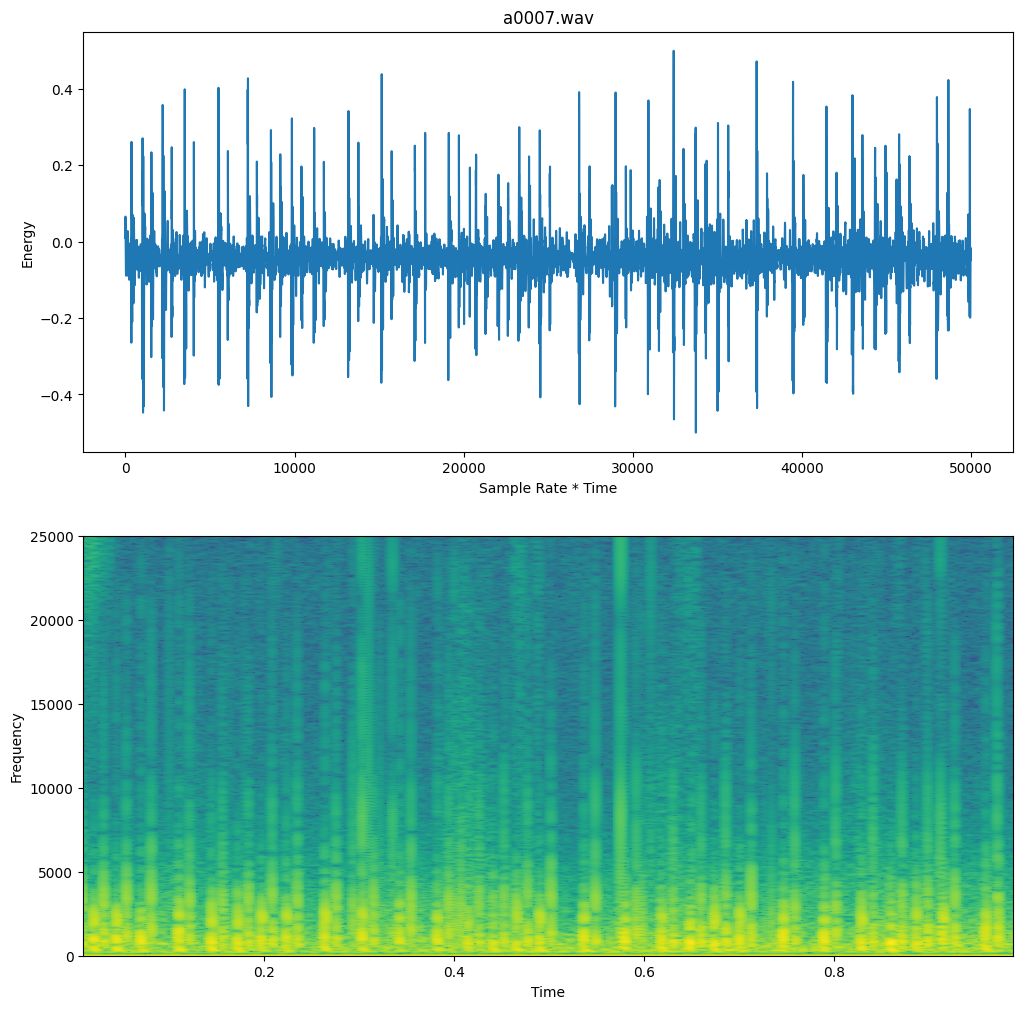

45

In [4]:
#Opening the wav file
signal_wave = wave.open(os.path.join(input_directory, wav[6]), 'r')

#Specifying sample_rate
sample_rate = 50000
sig = np.frombuffer(signal_wave.readframes(sample_rate), dtype=np.int16)

max_data = []
min_data = []

max_data = np.max(sig)
min_data = np.min(sig)
norm_signal = (sig - min_data)/(max_data - min_data)
sig = norm_signal - 0.5

#Creating the figure
plt.figure(figsize=(12,12))
sig_plot = plt.subplot(211)
sig_plot.set_title(wav[6])
sig_plot.plot(sig)
sig_plot.set_xlabel('Sample Rate * Time')
sig_plot.set_ylabel('Energy')

spectogram_plot = plt.subplot(212)
spectogram_plot.specgram(sig, NFFT=1024, Fs=sample_rate, noverlap=900)
spectogram_plot.set_xlabel('Time')
spectogram_plot.set_ylabel('Frequency')

plt.show()
gc.collect()

**Read all the .wav files and convert to spectogram and save as png in respective class folders**

In [ ]:
#To limit the signal to 5 seconds
def Limit(S,Fs):
    if(len(S)/Fs>=5):
        S=S[:5*Fs]
    else:
        for i in range(len(S),5*Fs):
            S=np.append(S,0)
    return S

#Function to get sound and frame info
def get_wav_info(wav_file):
    wav = wave.open(wav_file, 'r')
    frames = wav.readframes(-1)
    sound_info = pylab.frombuffer(frames, 'int16')
    frame_rate = wav.getframerate()
    wav.close()
    return sound_info, frame_rate

#Function to get the class label
def get_class(hea_file):

    #Reading the corresponding header file
    with open(input_directory+'/'+hea_file+'.hea') as f:
            lines = f.read().splitlines()
            last_line = lines[-1].split()[1]

    return last_line

#Output directory where the images of spectogram are stored
output_directory = '/content/drive/MyDrive/working/image_data/'

for filename in wav:

    #Making sure only wav files are read
    if "wav" in filename:

        file_path = os.path.join(input_directory, filename)
        file_stem = Path(file_path).stem

        #Getting the target directory
        target_dir = f'{get_class(file_stem)}'

        dist_dir = output_directory+target_dir.lower()

        file_dist_path = os.path.join(dist_dir, file_stem)

        #Converting signal to spectogram and saving as png
        if not os.path.exists(file_dist_path + '.png'):
            file_stem = Path(file_path).stem
            sound_info, frame_rate = get_wav_info(file_path)
            sig = Limit(sound_info,frame_rate)
            max_data = np.max(sig)
            min_data = np.min(sig)
            norm_signal = (sig - min_data)/(max_data - min_data)
            sig = norm_signal - 0.5
            pylab.specgram(sig, Fs=frame_rate)
            pylab.savefig(f'{file_dist_path}.png')
            pylab.close()

gc.collect()

KeyboardInterrupt: ignored

**Read all images and convert them to numpy arrays and also the class labels**
1. Read the image
2. Resize image to 128 x 128 x 3
3. Normalize image by taking max and min values for each image
4. Oversample the respective class if needed (If no augmentation, 3rd input must be greater than number of classes)

In [5]:
#To read the images into an array
from tqdm import tqdm
import cv2

#Properties of image
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
N_CHANNELS = 3

#Number of classes
N_CLASSES = 2

from skimage import transform
from tensorflow.keras import layers

def load_data(data,num_classes,class_label,augmen_times):

    X = []
    y = []

    #To traverse every spectogram image in data
    for file_type in os.listdir(data):

        if not file_type.startswith('.'):

        #It is binary classification so we have two class labels 0 and 1
        #If ABNORMAL the label will be 1
        #If NORMAL the label will be 0
            if file_type in ['abnormal']:
                label = 1
            elif file_type in ['normal']:
                label = 0

            for filename in tqdm(os.listdir(data + '/' + file_type)):
                #To read every image from the folders
                image = cv2.imread(data +'/'+ file_type + '/' + filename)

                #If the image is found
                if image is not None:

                    #To resize the random sized images into a fixed size of 128x128x3
                    image = transform.resize(image, (IMAGE_HEIGHT, IMAGE_WIDTH, N_CHANNELS))

                    #Changing the datatype into array to process through the cnn algorithm
                    image_data_as_arr = np.asarray(image)

                    del image

                    #Augmented addition abnormal images if detected
                    if(label==class_label and class_label<num_classes):
                        data_augmentation = tf.keras.Sequential([
                                             layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
                                            layers.experimental.preprocessing.RandomRotation(0.2)])
                        for i in range(augmen_times):
                            augmented_image = data_augmentation(image_data_as_arr)
                            X.append(augmented_image)
                            y.append(label)

                    #Appending the data in the empty lists of X and y
                    X.append(image_data_as_arr)
                    y.append(label)
    X = np.asarray(X)
    y = np.asarray(y)

    return X,y


#Loading the train data

X_train, y_train = load_data('/content/drive/MyDrive/working/image_data',2,1,3)
gc.collect()

100%|██████████| 665/665 [03:03<00:00,  3.63it/s]


69439

In [6]:
#Getting counts of each labels
unique, counts = np.unique(y_train, return_counts=True)
dict(zip(unique, counts))

{0: 2575, 1: 2660}

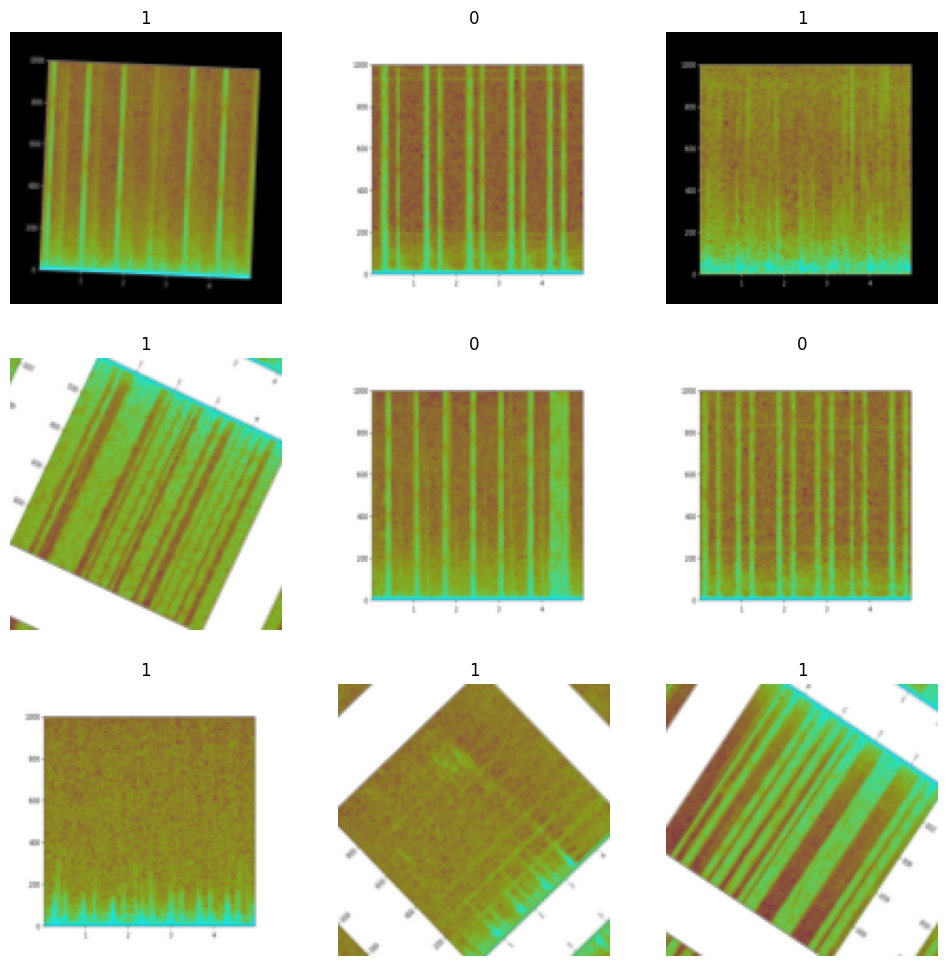

In [ ]:
import random
#Plotting all the spectogram images
plt.figure(figsize=(12, 12))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    rand_num = random.randint(0,len(X_train))
    plt.imshow(X_train[rand_num])
    plt.title(int(y_train[rand_num]))
    plt.axis("off")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical

#Splitting the train and test data
xTrain, xTest, yTrain, yTest = train_test_split(X_train, y_train, random_state=42, test_size=0.2)

#One hot encoding the labels
y_trainHot = np.uint8(to_categorical(yTrain, num_classes = 2))
y_testHot = np.uint8(to_categorical(yTest, num_classes = 2))

gc.collect()

#del X_train
#del y_train

0

**Make the CNN model and train the model with the respective parameters**

In [8]:
#The main CNN architecture
import keras
from keras import models
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, MaxPool2D
from sklearn.metrics import classification_report, confusion_matrix

#The binary labels for our CNN model in the form of a dictionary
bin_labels = {0:'Normal',1:'Abnormal'}

def CNN(imgs,img_labels,test_imgs,test_labels,stride):

    #Number of classes (2)
    num_classes = len(img_labels[0])

    epochs = 30

    #Size of image
    img_rows,img_cols=imgs.shape[1],imgs.shape[2]
    input_shape = (img_rows, img_cols, 3)

    #Creating the model
    model = Sequential()

    #First convolution layer
    model.add(Conv2D(32, kernel_size=(3, 3),
                     activation='relu',
                     input_shape=input_shape,
                     strides=stride))

    #First maxpooling layer
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Dropout(0.2))

    #Second convolution layer
    model.add(Conv2D(64, (3, 3), activation='relu'))

    #Second maxpooling layer
    model.add(MaxPooling2D(pool_size=(2, 2)))

    #Third convolution layer
    model.add(Conv2D(128, (3, 3), activation='relu'))

    #Third maxpooling layer
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Dropout(0.2))

    #Convert the matrix to a fully connected layer
    model.add(Flatten())

    #Dense function to convert FCL to 128 values
    model.add(Dense(128, activation='relu'))

    model.add(Dropout(0.2))

    #Dense function to convert FCL to 128 values
    model.add(Dense(128, activation='relu'))

    #Dense function to convert FCL to 128 values
    model.add(Dense(128, activation='relu'))

    #Final dense layer on which softmax function is performed
    model.add(Dense(num_classes, activation='softmax'))

    #Model parameters
    model.compile(loss='categorical_crossentropy',
                  optimizer='adamax',
                  metrics=['binary_accuracy'])

    #Evaluate the model on the test data before training your model
    score = model.evaluate(test_imgs,test_labels, verbose=1)

    print('\nKeras CNN binary accuracy:', score[1],'\n')

    #The model details
    history = model.fit(imgs,img_labels,
                        shuffle = True,
                        epochs=epochs,
                        validation_data = (test_imgs, test_labels))

    #Evaluate the model on the test data after training your model
    score = model.evaluate(test_imgs,test_labels, verbose=1)
    print('\nKeras CNN binary accuracy:', score[1],'\n')

    #Predict the labels from test data
    y_pred = model.predict(test_imgs)
    Y_pred_classes = np.argmax(y_pred,axis=1)
    Y_true = np.argmax(test_labels,axis=1)

    #Correct labels
    for i in range(len(Y_true)):
        if(Y_pred_classes[i] == Y_true[i]):
            print("The predicted class is : " , Y_pred_classes[i])
            print("The real class is : " , Y_true[i])
            break

    #The confusion matrix made from the real Y values and the predicted Y values
    confusion_mtx = [Y_true, Y_pred_classes]

    #Summary of the model
    model.summary()

    return model,confusion_mtx

model,conf_mat = CNN(xTrain,y_trainHot,xTest,y_testHot,1);

33/33 [==============================] - 8s 14ms/step - loss: 0.6910 - binary_accuracy: 0.6753

Keras CNN binary accuracy: 0.6752626299858093 

Epoch 1/30
131/131 [==============================] - 10s 34ms/step - loss: 0.3223 - binary_accuracy: 0.8744 - val_loss: 0.2808 - val_binary_accuracy: 0.8988
Epoch 2/30
131/131 [==============================] - 4s 28ms/step - loss: 0.2450 - binary_accuracy: 0.9026 - val_loss: 0.2662 - val_binary_accuracy: 0.9016
Epoch 3/30
131/131 [==============================] - 4s 31ms/step - loss: 0.2254 - binary_accuracy: 0.9107 - val_loss: 0.2400 - val_binary_accuracy: 0.9035
Epoch 4/30
131/131 [==============================] - 4s 30ms/step - loss: 0.2179 - binary_accuracy: 0.9057 - val_loss: 0.2291 - val_binary_accuracy: 0.9074
Epoch 5/30
131/131 [==============================] - 4s 28ms/step - loss: 0.2089 - binary_accuracy: 0.9126 - val_loss: 0.2367 - val_binary_accuracy: 0.9131
Epoch 6/30
131/131 [==============================] - 4s 28ms/step - l

In [9]:
gc.collect()

#Predict the labels from test data
y_pred = model.predict(xTest)
Y_pred_classes = np.argmax(y_pred,axis=1)
Y_true = np.argmax(y_testHot,axis=1)

from sklearn.metrics import precision_recall_fscore_support
prec,recall,f1,_ = precision_recall_fscore_support(Y_true,Y_pred_classes,average='binary')

print("Precision : ", prec)
print("Recall : ", recall)
print("F1 score : ", f1)

33/33 [==============================] - 0s 8ms/step
Precision :  0.9232245681381958
Recall :  0.9232245681381958
F1 score :  0.9232245681381958


Balanced Accuracy: 0.92


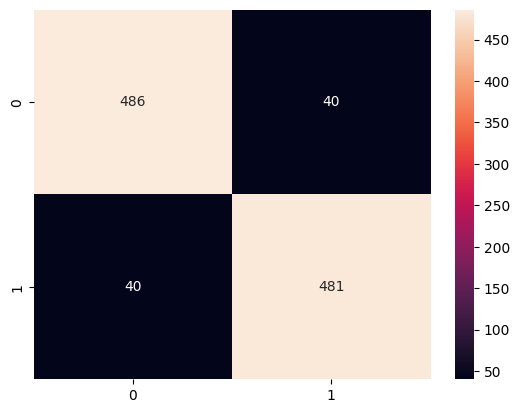

In [10]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
import seaborn as sns

# Compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

# Plot the confusion matrix
sns.heatmap(confusion_mtx, annot=True, fmt='d')

# Compute and print the balanced accuracy
balanced_acc = balanced_accuracy_score(Y_true, Y_pred_classes)
print(f'Balanced Accuracy: {balanced_acc:.2f}')
